# 05A - Store Sales Forecasting - Time Series Cross Validation

## Objective

Evaluate the advanced forecasting pipeline with a more robust validation strategy.

Main goals:

- move beyond a single temporal split
- evaluate model stability across multiple time windows
- obtain a more reliable estimate of model performance
- track cross-validation results with MLflow

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_log_error

sys.path.append(str(Path().resolve().parent))

from src.features import add_baseline_features, add_advanced_features, encode_family
from src.metrics import evaluate_regression

## Setup

Use the same project configuration adopted in the previous notebooks.

This keeps the dataset, feature engineering logic and model setup consistent,
so that the only change is the validation strategy.

In [2]:
SEED = 42
DATA_DIR = Path("../data")
USE_FULL_DATA = False
LAST_N_DAYS = 365

MLFLOW_EXPERIMENT_NAME = "store_sales_forecasting"
MLFLOW_TRACKING_URI = "file:../mlruns"

print("Setup OK")
print("Data dir:", DATA_DIR.resolve())
print("MLflow tracking uri:", MLFLOW_TRACKING_URI)

Setup OK
Data dir: /home/donatocorbacio/projects/store-sales-project/data
MLflow tracking uri: file:../mlruns


## MLflow setup

Track the full cross-validation experiment as a single MLflow run.

This makes the experiment easier to inspect and compare with previous notebooks.

In [3]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

print("Active experiment:", MLFLOW_EXPERIMENT_NAME)

Active experiment: store_sales_forecasting


## Load data

Load the Store Sales dataset and inspect the date range.

In [4]:
train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["date"])
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["date"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train range:", train["date"].min(), "->", train["date"].max())
print("Test range:", test["date"].min(), "->", test["date"].max())

Train shape: (3000888, 6)
Test shape: (28512, 5)
Train range: 2013-01-01 00:00:00 -> 2017-08-15 00:00:00
Test range: 2017-08-16 00:00:00 -> 2017-08-31 00:00:00


## Sorting

Sort by store, family and date to preserve temporal consistency.

In [5]:
train = train.sort_values(["store_nbr", "family", "date"]).copy()
test = test.sort_values(["store_nbr", "family", "date"]).copy()

print("Sorting completed.")
display(train.head())

Sorting completed.


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0


## Temporal subset

Use the last 365 days to keep experiments fast and consistent with NB1-NB4.

This ensures that cross-validation results remain comparable with previous experiments.

In [6]:
if not USE_FULL_DATA:
    cutoff = train["date"].max() - pd.Timedelta(days=LAST_N_DAYS)
    train = train[train["date"] >= cutoff].copy()

print("Train shape after subset:", train.shape)
print("New date range:", train["date"].min(), "->", train["date"].max())

Train shape after subset: (650430, 6)
New date range: 2016-08-15 00:00:00 -> 2017-08-15 00:00:00


## Base time features

Create the common calendar features used in the previous notebooks.

In [7]:
for df in [train, test]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

display(train[["date", "year", "month", "day", "dayofweek", "weekofyear", "is_weekend"]].head())

,date,year,month,day,dayofweek,weekofyear,is_weekend
2350458,2016-08-15,2016,8,15,0,33,0
2352240,2016-08-16,2016,8,16,1,33,0
2354022,2016-08-17,2016,8,17,2,33,0
2355804,2016-08-18,2016,8,18,3,33,0
2357586,2016-08-19,2016,8,19,4,33,0


## Rebuild advanced feature set

Reuse the same advanced pipeline introduced in NB3 and tracked in NB4.

This keeps the model configuration unchanged and isolates the effect of the new validation strategy.

In [8]:
advanced_train = add_baseline_features(train)
advanced_train = add_advanced_features(advanced_train)
advanced_train = advanced_train.dropna().copy()

advanced_train, advanced_test, family_mapping = encode_family(advanced_train, test)

advanced_features = [
    "store_nbr",
    "family",
    "onpromotion",
    "year",
    "month",
    "day",
    "dayofweek",
    "weekofyear",
    "is_weekend",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_14",
    "trend_1_7",
    "promo_last_7",
]

print("Advanced dataset shape:", advanced_train.shape)
print("Number of features:", len(advanced_features))
print("Date range:", advanced_train["date"].min(), "->", advanced_train["date"].max())

Advanced dataset shape: (625482, 19)
Number of features: 16
Date range: 2016-08-29 00:00:00 -> 2017-08-15 00:00:00


## Walk-forward validation strategy

Instead of using a single validation split, use multiple temporal folds.

In each fold:

- the training window expands forward in time
- the validation window moves to the next period

This provides a more robust estimate of model performance across time.

In [9]:
unique_dates = np.array(sorted(advanced_train["date"].unique()))

n_folds = 3
val_size = 28  # 4 weeks
min_train_size = 180  # at least ~6 months

folds = []

for i in range(n_folds):
    train_end_idx = min_train_size - 1 + i * val_size
    val_start_idx = train_end_idx + 1
    val_end_idx = val_start_idx + val_size - 1

    if val_end_idx >= len(unique_dates):
        break

    train_end = unique_dates[train_end_idx]
    val_start = unique_dates[val_start_idx]
    val_end = unique_dates[val_end_idx]

    folds.append({
        "fold": i + 1,
        "train_end": train_end,
        "val_start": val_start,
        "val_end": val_end,
    })

folds_df = pd.DataFrame(folds)
display(folds_df)

,fold,train_end,val_start,val_end
0,1,2017-02-25,2017-02-26,2017-03-25
1,2,2017-03-25,2017-03-26,2017-04-22
2,3,2017-04-22,2017-04-23,2017-05-20


## Fold inspection

Check the train/validation boundaries before running cross-validation.

In [10]:
for fold_info in folds:
    print(
        f"Fold {fold_info['fold']} | "
        f"train <= {pd.Timestamp(fold_info['train_end']).date()} | "
        f"val: {pd.Timestamp(fold_info['val_start']).date()} -> {pd.Timestamp(fold_info['val_end']).date()}"
    )

Fold 1 | train <= 2017-02-25 | val: 2017-02-26 -> 2017-03-25
Fold 2 | train <= 2017-03-25 | val: 2017-03-26 -> 2017-04-22
Fold 3 | train <= 2017-04-22 | val: 2017-04-23 -> 2017-05-20


## Cross-validation experiment

Train and evaluate the advanced LightGBM model across all folds.

For each fold:

- fit the model on the training window
- predict on the validation window
- compute RMSLE and supporting metrics

Then summarize:

- fold-by-fold metrics
- mean performance
- standard deviation

In [11]:
cv_results = []

with mlflow.start_run(run_name="lgbm_advanced_v1_walk_forward_cv"):
    mlflow.set_tags({
        "project": "store_sales_forecasting",
        "notebook": "nb5",
        "model_family": "lightgbm",
        "experiment_type": "time_series_cross_validation",
        "validation_strategy": "walk_forward",
        "primary_metric": "rmsle_mean",
    })

    mlflow.log_params({
        "model_type": "LGBMRegressor",
        "feature_set": "advanced_v1",
        "n_estimators": 300,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "random_state": SEED,
        "last_n_days": LAST_N_DAYS,
        "use_full_data": USE_FULL_DATA,
        "n_features": len(advanced_features),
        "n_folds": len(folds),
        "val_size_days": val_size,
        "min_train_size_days": min_train_size,
    })

    for fold_info in folds:
        fold = fold_info["fold"]
        train_end = fold_info["train_end"]
        val_start = fold_info["val_start"]
        val_end = fold_info["val_end"]

        train_fold = advanced_train[advanced_train["date"] <= train_end].copy()
        val_fold = advanced_train[
            (advanced_train["date"] >= val_start) &
            (advanced_train["date"] <= val_end)
        ].copy()

        X_train = train_fold[advanced_features]
        y_train = train_fold["sales"]

        X_val = val_fold[advanced_features]
        y_val = val_fold["sales"]

        model = LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=SEED,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        y_pred = np.clip(y_pred, 0, None)

        metrics = evaluate_regression(y_val, y_pred)

        row = {
            "fold": fold,
            "train_end": train_end,
            "val_start": val_start,
            "val_end": val_end,
            "n_train": len(train_fold),
            "n_val": len(val_fold),
            **metrics,
        }
        cv_results.append(row)

        mlflow.log_metric(f"rmsle_fold_{fold}", metrics["rmsle"])
        mlflow.log_metric(f"mae_fold_{fold}", metrics["mae"])
        mlflow.log_metric(f"rmse_fold_{fold}", metrics["rmse"])
        mlflow.log_metric(f"r2_fold_{fold}", metrics["r2"])

        print(
            f"Fold {fold} | "
            f"RMSLE={metrics['rmsle']:.6f} | "
            f"MAE={metrics['mae']:.3f} | "
            f"RMSE={metrics['rmse']:.3f} | "
            f"R2={metrics['r2']:.6f}"
        )

    cv_results_df = pd.DataFrame(cv_results)

    rmsle_mean = cv_results_df["rmsle"].mean()
    rmsle_std = cv_results_df["rmsle"].std()

    mae_mean = cv_results_df["mae"].mean()
    rmse_mean = cv_results_df["rmse"].mean()
    r2_mean = cv_results_df["r2"].mean()

    mlflow.log_metric("rmsle_mean", float(rmsle_mean))
    mlflow.log_metric("rmsle_std", float(rmsle_std))
    mlflow.log_metric("mae_mean", float(mae_mean))
    mlflow.log_metric("rmse_mean", float(rmse_mean))
    mlflow.log_metric("r2_mean", float(r2_mean))

    print("\nCross-validation completed.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003359 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2178
[LightGBM] [Info] Number of data points in the train set: 320760, number of used features: 16
[LightGBM] [Info] Start training from score 467.224693
Fold 1 | RMSLE=0.668859 | MAE=74.018 | RMSE=285.740 | R2=0.957877
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016788 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2186
[LightGBM] [Info] Number of data points in the train set: 370656, number of used features: 16
[LightGBM] [Info] Start training from score 469.738601
Fold 2 | RMSLE=0.727673 | MAE=77.916 | RMSE=321.462 | R2=0.946110
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007450 seconds.
You can se

## Cross-validation results

Inspect fold-by-fold performance and average metrics.

In [12]:
display(cv_results_df)

,fold,train_end,val_start,val_end,n_train,n_val,rmsle,mae,rmse,r2
0,1,2017-02-25,2017-02-26,2017-03-25,320760,49896,0.668859,74.017598,285.740415,0.957877
1,2,2017-03-25,2017-03-26,2017-04-22,370656,49896,0.727673,77.915584,321.461746,0.946110
2,3,2017-04-22,2017-04-23,2017-05-20,420552,49896,0.664711,75.407449,286.419166,0.955873


In [13]:
summary = pd.DataFrame([{
    "rmsle_mean": cv_results_df["rmsle"].mean(),
    "rmsle_std": cv_results_df["rmsle"].std(),
    "mae_mean": cv_results_df["mae"].mean(),
    "rmse_mean": cv_results_df["rmse"].mean(),
    "r2_mean": cv_results_df["r2"].mean(),
}])

display(summary)

,rmsle_mean,rmsle_std,mae_mean,rmse_mean,r2_mean
0,0.687081,0.035215,75.78021,297.873776,0.953287


## Comparison with NB4

Compare the walk-forward result with the single-split result obtained in NB4.

NB4 advanced model:
- RMSLE ≈ 0.68

NB5:
- mean RMSLE across folds
- standard deviation across folds

This helps assess whether the model performance is stable or highly dependent on a single validation window.

In [14]:
nb4_rmsle = 0.6801390821651269

comparison_df = pd.DataFrame([
    {
        "evaluation": "NB4 single split",
        "rmsle": nb4_rmsle,
    },
    {
        "evaluation": "NB5 walk-forward mean",
        "rmsle": cv_results_df["rmsle"].mean(),
    },
])

display(comparison_df)

,evaluation,rmsle
0,NB4 single split,0.680139
1,NB5 walk-forward mean,0.687081


In [15]:
print("NB4 single split RMSLE:", round(nb4_rmsle, 6))
print("NB5 walk-forward mean RMSLE:", round(cv_results_df["rmsle"].mean(), 6))
print("NB5 walk-forward std:", round(cv_results_df["rmsle"].std(), 6))

NB4 single split RMSLE: 0.680139
NB5 walk-forward mean RMSLE: 0.687081
NB5 walk-forward std: 0.035215


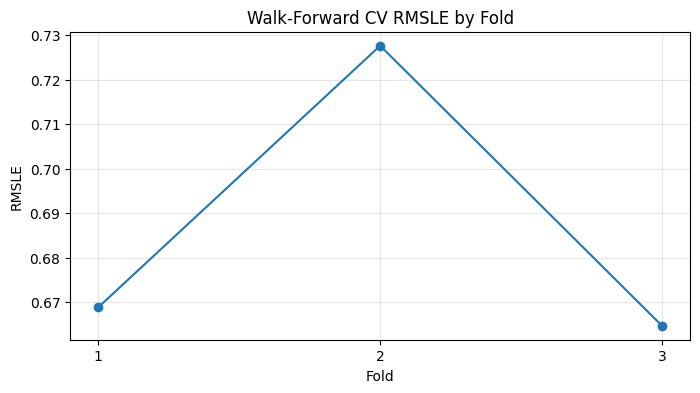

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(cv_results_df["fold"], cv_results_df["rmsle"], marker="o")
plt.title("Walk-Forward CV RMSLE by Fold")
plt.xlabel("Fold")
plt.ylabel("RMSLE")
plt.xticks(cv_results_df["fold"])
plt.grid(True, alpha=0.3)
plt.show()

## Interpretation

If the fold scores are close to each other, the model is relatively stable across time.

If the fold scores vary a lot, model performance depends more strongly on the validation period.

This provides a more realistic estimate of forecasting robustness than a single split.

## Insights

- Model performance varies across folds (std ≈ 0.035)
- Fold 2 shows significantly higher error → potential temporal instability
- Single split evaluation (NB4) slightly optimistic
- Cross-validation provides a more realistic estimate

## Conclusion

This notebook extends the evaluation pipeline by introducing walk-forward time series cross-validation.

Main outcomes:

- the advanced model is evaluated across multiple temporal folds
- performance is summarized with mean and standard deviation
- the validation process becomes more robust than a single split
- MLflow tracks the full cross-validation experiment as a structured run

This step moves the project closer to a more realistic forecasting workflow used in production settings.